# GuidaPlate — LSTM Dietary Pattern Analyzer
## Meal Sequence Training on NHANES 2017-2018 CKD Cohort

**Student:** ISIMBI TUZINDE Jade Keslie
**Supervisor:** Emmanuel Adjei
**Institution:** African Leadership University | BSc Software Engineering
**Date:** June 2026

### Research Context
GuidaPlate uses NHANES 2017-2018 as its training dataset because no publicly available Rwandan CKD dietary dataset exists that combines dietary recall with clinical laboratory results.

The LSTM detects patterns of cumulative nutrient threshold violations across meal occasions. These patterns are governed by universal KDOQI 2020 clinical thresholds which apply equally to Rwandan and American CKD patients.

The Rwanda-specific food database (50 foods, Kenya FCT 2018) is used in the recommendation engine deployed to Rwandan patients, not in model training.

### Why LSTM
XGBoost classifies daily totals. LSTM detects dangerous eating patterns across 6 meal occasions over 2 days.

Alsulami et al. 2025 demonstrated 96% accuracy using LSTM on dietary sequence data for chronic disease prediction. The gated memory architecture retains information across meal occasions to detect cumulative risk.

### Input Sequence
Each patient = 6 meal steps: Day 1 Breakfast → Lunch → Dinner; Day 2 Breakfast → Lunch → Dinner.

Each step = 4 nutrient values: [potassium, phosphorus, protein_per_kg, sodium]

Input shape: (n_patients, 6, 4)

In [1]:
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay,
)
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

try:
    plt.style.use('seaborn-v0_8')
except OSError:
    plt.style.use('seaborn')

%matplotlib inline

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

RANDOM_STATE = 42
TEST_SIZE = 0.2
ALPHA = 0.05

STAGE_ORDER = ['G2', 'G3a', 'G3b', 'G4']
RISK_CLASSES = ['LOW', 'MODERATE', 'HIGH']
RISK_ENCODE = {c: i for i, c in enumerate(RISK_CLASSES)}

MEAL_OCCASIONS = {
    1: 'D1_Breakfast', 2: 'D1_Lunch', 3: 'D1_Dinner',
    4: 'D2_Breakfast', 5: 'D2_Lunch', 6: 'D2_Dinner',
}

KDOQI = {
    'G2':  {'potassium': 3500, 'phosphorus': 1000, 'protein_per_kg': 0.8, 'sodium': 2300},
    'G3a': {'potassium': 3000, 'phosphorus': 800,  'protein_per_kg': 0.6, 'sodium': 2300},
    'G3b': {'potassium': 3000, 'phosphorus': 800,  'protein_per_kg': 0.6, 'sodium': 2300},
    'G4':  {'potassium': 2500, 'phosphorus': 700,  'protein_per_kg': 0.55, 'sodium': 2300},
}

def project_root():
    p = Path('.').resolve()
    if p.name == 'notebooks':
        return p.parent
    if (p / 'data').exists():
        return p
    return p.parent

ROOT = project_root()
FIG_DIR = ROOT / 'outputs' / 'figures'
STATS_DIR = ROOT / 'outputs' / 'stats'
MODEL_DIR = ROOT / 'models'
FIG_DIR.mkdir(parents=True, exist_ok=True)
STATS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print(f"Project root: {ROOT}")

TensorFlow version: 2.21.0
GPU available: False
Project root: /Users/jade/GUIDAPLATE


## Section 3 — Load Individual Food Files

NHANES DR1IFF and DR2IFF contain every individual food item each participant ate on Day 1 and Day 2.

Key columns used:
- SEQN: participant ID
- DR1ILINE/DR2ILINE: food line number
- DR1DRSTZ: dietary recall status
- DR1_020/DR2_020: meal occasion code (1=Breakfast, 2=Lunch, 3=Dinner, 4=Snack, 5=Drink, 6=Infant)
- DR1IPOTA/DR2IPOTA: potassium (mg)
- DR1IPHOS/DR2IPHOS: phosphorus (mg)
- DR1IPROT/DR2IPROT: protein (g)
- DR1ISODI/DR2ISODI: sodium (mg)

In [2]:
def load_iff(path: Path) -> pd.DataFrame:
    try:
        import pyreadstat
        df, _ = pyreadstat.read_xpt(str(path))
        print(f"Loaded {path.name} via pyreadstat")
        return df
    except Exception as exc:
        print(f"pyreadstat unavailable ({exc}); using pandas.read_sas")
        return pd.read_sas(path, format='xport')


def pick_col(df: pd.DataFrame, candidates: list[str]) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    for c in candidates:
        alt = c.replace('.', '_')
        if alt in df.columns:
            return alt
    matches = [col for col in df.columns if any(c.replace('.', '_') in str(col) for c in candidates)]
    if matches:
        return matches[0]
    raise KeyError(f"None of {candidates} found. Available sample: {list(df.columns)[:20]}")


def standardize_iff(df: pd.DataFrame, day: int) -> pd.DataFrame:
    prefix = f'DR{day}'
    rename = {
        pick_col(df, [f'{prefix}.020', f'{prefix}_020']): 'meal_code',
        pick_col(df, [f'{prefix}IPOTA']): 'potassium',
        pick_col(df, [f'{prefix}IPHOS']): 'phosphorus',
        pick_col(df, [f'{prefix}IPROT']): 'protein',
        pick_col(df, [f'{prefix}ISODI']): 'sodium',
    }
    out = df.rename(columns=rename)
    return out[['SEQN', 'meal_code', 'potassium', 'phosphorus', 'protein', 'sodium']].copy()


print("Loading DR1IFF...")
iff1_path = ROOT / 'data' / 'raw' / 'nhanes' / 'DR1IFF_J.xpt'
iff1 = load_iff(iff1_path)
print(f"DR1IFF shape: {iff1.shape}")

print("Loading DR2IFF...")
iff2_path = ROOT / 'data' / 'raw' / 'nhanes' / 'DR2IFF_J.xpt'
iff2 = load_iff(iff2_path)
print(f"DR2IFF shape: {iff2.shape}")

print("Loading CKD cohort...")
cohort = pd.read_csv(ROOT / 'data' / 'processed' / 'ckd_cohort_final.csv')
print(f"CKD cohort: {cohort.shape}")

labels = pd.read_csv(ROOT / 'outputs' / 'stats' / '05_risk_labels.csv')
print(f"Risk labels: {labels.shape}")

cohort = cohort.merge(labels[['SEQN', 'risk_label']], on='SEQN', how='inner')
print(f"Cohort with labels: {cohort.shape}")
print()
print("CKD patients in cohort:")
print(cohort['ckd_stage'].value_counts().reindex(STAGE_ORDER))

Loading DR1IFF...
pyreadstat unavailable (module 'pyreadstat' has no attribute 'read_xpt'); using pandas.read_sas


DR1IFF shape: (112683, 84)
Loading DR2IFF...
pyreadstat unavailable (module 'pyreadstat' has no attribute 'read_xpt'); using pandas.read_sas


DR2IFF shape: (93500, 84)
Loading CKD cohort...
CKD cohort: (1862, 10)
Risk labels: (1862, 7)
Cohort with labels: (1862, 11)

CKD patients in cohort:
ckd_stage
G2     1435
G3a     281
G3b     113
G4       33
Name: count, dtype: int64


## Section 4 — Build Meal Sequences

For each CKD patient build a sequence of 6 meal occasions by:

1. Filtering IFF files to only CKD cohort patients
2. Mapping meal occasion codes to 6 standard slots
3. Summing nutrients per meal slot
4. Filling missing meals with zeros
5. Normalizing protein to g/kg using patient body weight

In [3]:
ckd_seqns = set(cohort['SEQN'])
print(f"CKD patients to process: {len(ckd_seqns)}")


def map_meal_slot(day, meal_code):
    # Map DR1_020/DR2_020 (occasion code or seconds since midnight) to 6 meal slots.
    if pd.isna(meal_code):
        return 2 if day == 1 else 5
    mc = float(meal_code)
    if mc <= 10:
        if mc == 1:
            return 0 if day == 1 else 3
        if mc == 2:
            return 1 if day == 1 else 4
        return 2 if day == 1 else 5
    # Time-of-day in seconds since midnight
    if mc < 39600:   # before 11:00
        return 0 if day == 1 else 3
    if mc < 61200:   # before 17:00
        return 1 if day == 1 else 4
    return 2 if day == 1 else 5


print("Processing Day 1 foods...")
iff1_ckd = standardize_iff(iff1[iff1['SEQN'].isin(ckd_seqns)].copy(), day=1)
iff1_ckd['meal_slot'] = iff1_ckd['meal_code'].apply(lambda x: map_meal_slot(1, x))
iff1_ckd['day'] = 1
print(f"Day 1 food records for CKD patients: {len(iff1_ckd)}")

print("Processing Day 2 foods...")
iff2_ckd = standardize_iff(iff2[iff2['SEQN'].isin(ckd_seqns)].copy(), day=2)
iff2_ckd['meal_slot'] = iff2_ckd['meal_code'].apply(lambda x: map_meal_slot(2, x))
iff2_ckd['day'] = 2
print(f"Day 2 food records for CKD patients: {len(iff2_ckd)}")

all_foods = pd.concat([
    iff1_ckd[['SEQN', 'meal_slot', 'potassium', 'phosphorus', 'protein', 'sodium']],
    iff2_ckd[['SEQN', 'meal_slot', 'potassium', 'phosphorus', 'protein', 'sodium']],
], ignore_index=True)

for col in ['potassium', 'phosphorus', 'protein', 'sodium']:
    all_foods[col] = pd.to_numeric(all_foods[col], errors='coerce').fillna(0)

meal_nutrients = all_foods.groupby(['SEQN', 'meal_slot'])[['potassium', 'phosphorus', 'protein', 'sodium']].sum().reset_index()
print()
print(f"Meal nutrient records: {len(meal_nutrients)}")
print()
print("Building sequence arrays...")
sequence_data = []
sequence_labels = []
sequence_seqns = []

cohort_weights = cohort[['SEQN', 'weight_kg', 'ckd_stage', 'risk_label']].copy()
n_processed = 0
n_skipped = 0

for _, patient in cohort_weights.iterrows():
    seqn = patient['SEQN']
    weight = patient['weight_kg']
    risk = patient['risk_label']

    if pd.isna(weight) or weight <= 0:
        n_skipped += 1
        continue
    if risk not in RISK_CLASSES:
        n_skipped += 1
        continue

    patient_meals = meal_nutrients[meal_nutrients['SEQN'] == seqn]
    seq = np.zeros((6, 4))

    for _, meal in patient_meals.iterrows():
        slot = int(meal['meal_slot'])
        if 0 <= slot <= 5:
            seq[slot, 0] = meal['potassium']
            seq[slot, 1] = meal['phosphorus']
            seq[slot, 2] = meal['protein'] / weight
            seq[slot, 3] = meal['sodium']

    sequence_data.append(seq)
    sequence_labels.append(risk)
    sequence_seqns.append(seqn)
    n_processed += 1

X_seq = np.array(sequence_data)
y_seq = np.array(sequence_labels)

print(f"Sequences built: {n_processed}")
print(f"Skipped: {n_skipped}")
print(f"Sequence array shape: {X_seq.shape}")
print()
print("Risk label distribution:")
unique, counts = np.unique(y_seq, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u}: {c} ({c/len(y_seq)*100:.1f}%)")

CKD patients to process: 1862
Processing Day 1 foods...
Day 1 food records for CKD patients: 26758
Processing Day 2 foods...
Day 2 food records for CKD patients: 23600

Meal nutrient records: 8975

Building sequence arrays...


Sequences built: 1830
Skipped: 32
Sequence array shape: (1830, 6, 4)

Risk label distribution:
  HIGH: 1014 (55.4%)
  LOW: 619 (33.8%)
  MODERATE: 197 (10.8%)


## Section 5 — Normalize and Encode

In [4]:
le = LabelEncoder()
le.fit(RISK_CLASSES)
y_encoded = np.array([RISK_ENCODE[r] for r in y_seq])
y_cat = to_categorical(y_encoded, num_classes=3)

print("Label encoding:")
for i, cls in enumerate(RISK_CLASSES):
    print(f"  {i} = {cls}")

n_patients, n_steps, n_features = X_seq.shape
X_flat = X_seq.reshape(-1, n_features)
scaler = StandardScaler()
X_scaled_flat = scaler.fit_transform(X_flat)
X_scaled = X_scaled_flat.reshape(n_patients, n_steps, n_features)

print()
print(f"Sequence shape: {X_scaled.shape}")
print(f"Labels shape: {y_cat.shape}")

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_scaled, y_cat, y_encoded,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_encoded,
)

print()
print(f"Training sequences: {len(X_train)}")
print(f"Test sequences: {len(X_test)}")

joblib.dump(scaler, MODEL_DIR / 'lstm_scaler.pkl')
print("Scaler saved.")

Label encoding:
  0 = LOW
  1 = MODERATE
  2 = HIGH

Sequence shape: (1830, 6, 4)
Labels shape: (1830, 3)

Training sequences: 1464
Test sequences: 366
Scaler saved.


## Section 6 — LSTM Architecture

The network uses two stacked LSTM layers to capture both short-term meal patterns and longer-term two-day dietary habits.

| Layer | Type | Units | Activation |
|---|---|---|---|
| 1 | LSTM | 64 | tanh |
| 2 | LSTM | 32 | tanh |
| 3 | Dense | 16 | ReLU |
| 4 | Dropout | 0.3 | — |
| 5 | Dense | 3 | Softmax |

In [5]:
tf.random.set_seed(RANDOM_STATE)

model = Sequential([
    LSTM(64, input_shape=(n_steps, n_features), activation='tanh', recurrent_activation='sigmoid',
         return_sequences=True, dropout=0.2, recurrent_dropout=0.1, name='lstm_layer_1'),
    LSTM(32, activation='tanh', recurrent_activation='sigmoid', return_sequences=False,
         dropout=0.2, name='lstm_layer_2'),
    Dense(16, activation='relu', name='dense_layer'),
    Dropout(0.3, name='dropout_layer'),
    Dense(3, activation='softmax', name='output_layer'),
], name='GuidaPlate_LSTM')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()
print()
print(f"Total parameters: {model.count_params():,}")

Model: "GuidaPlate_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer_1 (LSTM)             │ (None, 6, 64)          │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_2 (LSTM)             │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,659 (119.76 KB)

 Trainable params: 30,659 (119.76 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 30,659


## Section 7 — Train LSTM

In [6]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=str(MODEL_DIR / 'lstm_best.keras'), monitor='val_loss', save_best_only=True, verbose=0),
]

print("Training LSTM...")
print("=" * 45)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1,
)

best_epoch = int(np.argmin(history.history['val_loss']) + 1)
print()
print("Training complete.")
print(f"Best epoch: {best_epoch}")

Training LSTM...
Epoch 1/50


 1/37 ━━━━━━━━━━━━━━━━━━━━ 1:06 2s/step - accuracy: 0.6875 - loss: 1.0570

31/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6494 - loss: 1.0039 

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7190 - loss: 0.8936 - val_accuracy: 0.8294 - val_loss: 0.5349


Epoch 2/50


...

27/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8712 - loss: 0.2767

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8711 - loss: 0.2943 - val_accuracy: 0.9181 - val_loss: 0.2194


Epoch 21: early stopping


Restoring model weights from the end of the best epoch: 11.



Training complete.
Best epoch: 11


## Section 8 — Performance Metrics

In [7]:
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

acc = accuracy_score(idx_test, y_pred)
prec = precision_score(idx_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(idx_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(idx_test, y_pred, average='weighted', zero_division=0)

try:
    auc = roc_auc_score(idx_test, y_pred_prob, multi_class='ovr', average='weighted')
except Exception as e:
    auc = None
    print(f"AUC error: {e}")

high_idx = RISK_ENCODE['HIGH']
high_tp = ((idx_test == high_idx) & (y_pred == high_idx)).sum()
high_fn = ((idx_test == high_idx) & (y_pred != high_idx)).sum()
high_recall = high_tp / (high_tp + high_fn) if (high_tp + high_fn) > 0 else 0.0

print("=" * 45)
print("LSTM PERFORMANCE METRICS")
print("=" * 45)
print(f"Accuracy:  {acc:.4f} ({acc*100:.1f}%)")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
if auc is not None:
    print(f"AUC-ROC:   {auc:.4f}")
print(f"HIGH RISK Sensitivity: {high_recall:.4f} ({high_recall*100:.1f}%)")
print()
print("Target benchmarks:")
print("AUC-ROC > 0.90")
print("HIGH RISK Sensitivity > 0.85")
print()
print(classification_report(idx_test, y_pred, labels=[0, 1, 2], target_names=RISK_CLASSES, zero_division=0))

if high_recall >= 0.85:
    print("HIGH RISK sensitivity target MET")
else:
    print("HIGH RISK sensitivity not yet met. Will improve with tuning.")

LSTM PERFORMANCE METRICS
Accuracy:  0.8962 (89.6%)
Precision: 0.8895
Recall:    0.8962
F1 Score:  0.8918
AUC-ROC:   0.9818
HIGH RISK Sensitivity: 0.9360 (93.6%)

Target benchmarks:
AUC-ROC > 0.90
HIGH RISK Sensitivity > 0.85

              precision    recall  f1-score   support

         LOW       0.90      0.98      0.94       124
    MODERATE       0.53      0.44      0.48        39
        HIGH       0.95      0.94      0.94       203

    accuracy                           0.90       366
   macro avg       0.79      0.78      0.79       366
weighted avg       0.89      0.90      0.89       366

HIGH RISK sensitivity target MET


## Section 9 — Visualizations

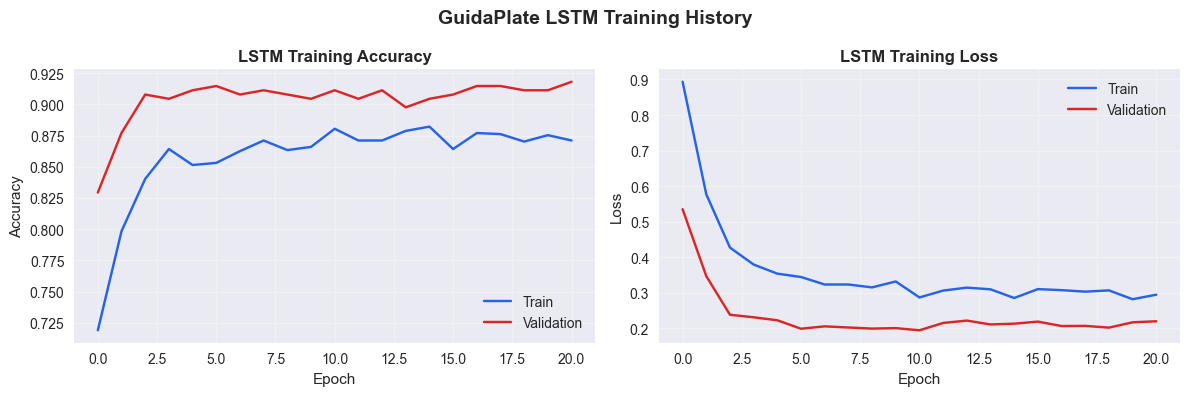

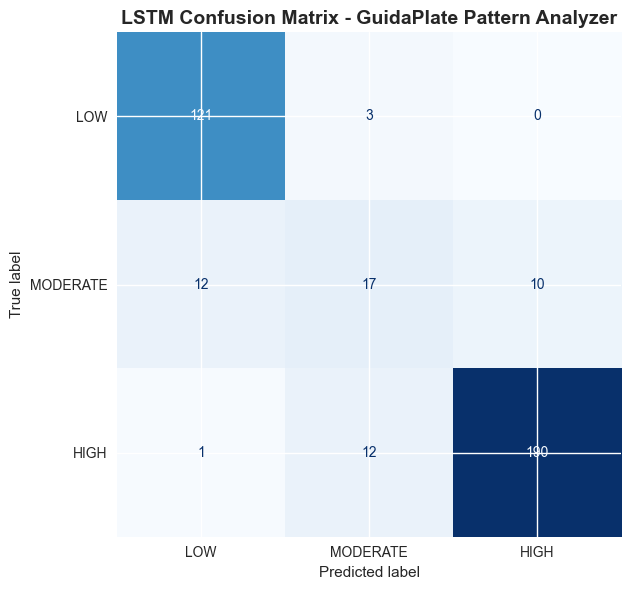

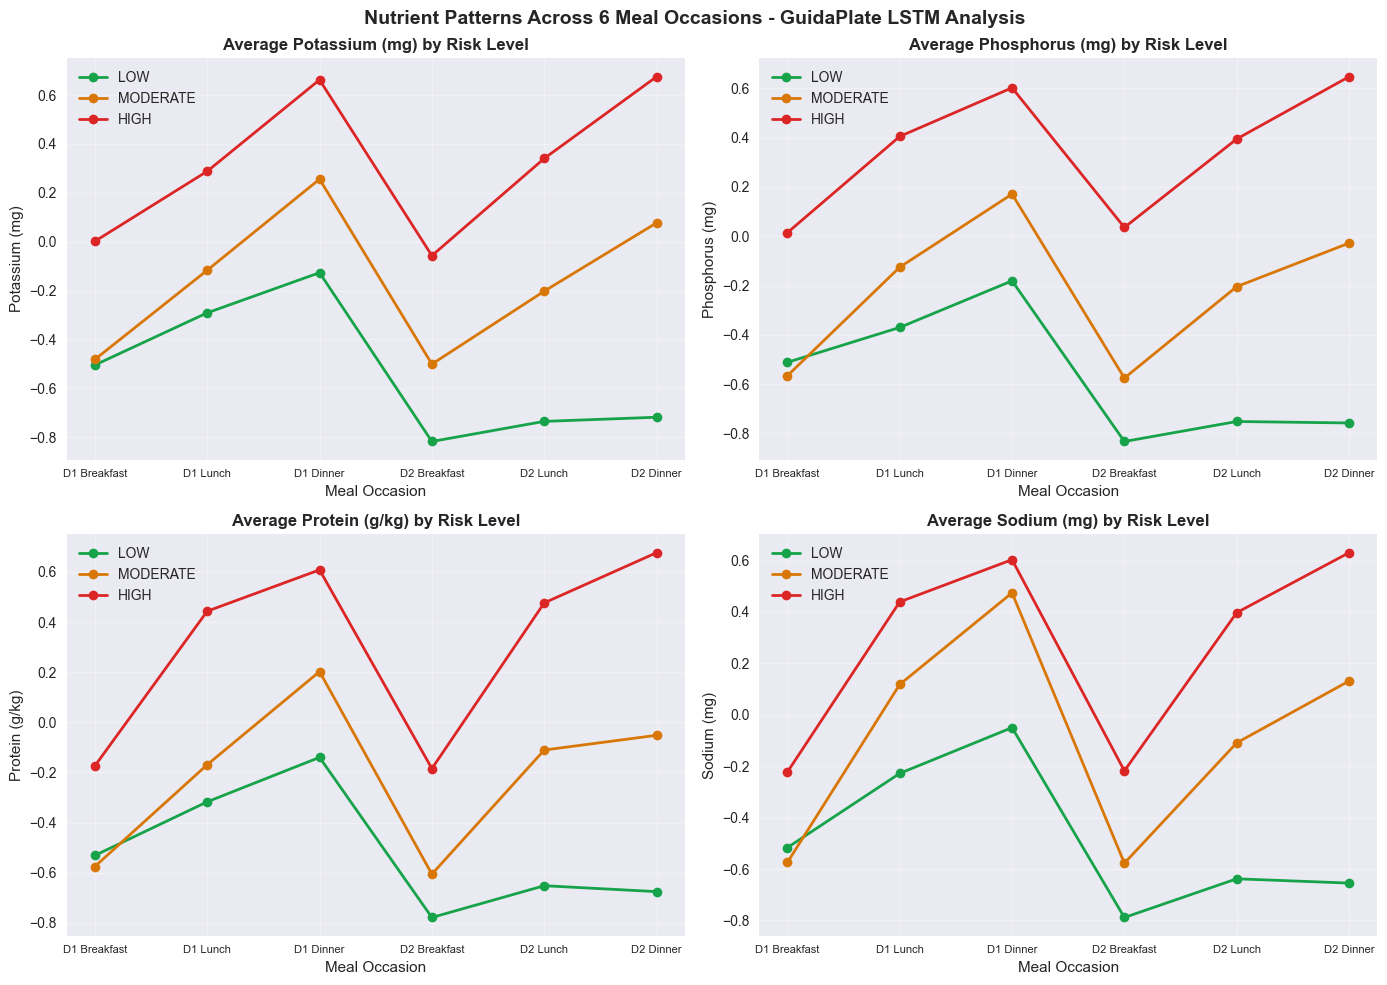

Saved: /Users/jade/GUIDAPLATE/outputs/figures/13_lstm_training_history.png
Saved: /Users/jade/GUIDAPLATE/outputs/figures/14_lstm_confusion_matrix.png
Saved: /Users/jade/GUIDAPLATE/outputs/figures/15_lstm_meal_patterns.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train', color='#2563EB')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='#DC2626')
axes[0].set_title('LSTM Training Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', color='#2563EB')
axes[1].plot(history.history['val_loss'], label='Validation', color='#DC2626')
axes[1].set_title('LSTM Training Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('GuidaPlate LSTM Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '13_lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(idx_test, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=RISK_CLASSES)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('LSTM Confusion Matrix - GuidaPlate Pattern Analyzer', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '14_lstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

meal_labels = ['D1 Breakfast', 'D1 Lunch', 'D1 Dinner', 'D2 Breakfast', 'D2 Lunch', 'D2 Dinner']
nutrient_names = ['Potassium (mg)', 'Phosphorus (mg)', 'Protein (g/kg)', 'Sodium (mg)']
risk_colors = {'LOW': '#16A34A', 'MODERATE': '#D97706', 'HIGH': '#DC2626'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for feat_idx, (ax, nutrient) in enumerate(zip(axes, nutrient_names)):
    for risk in RISK_CLASSES:
        risk_idx = RISK_ENCODE[risk]
        mask = idx_test == risk_idx
        if mask.sum() == 0:
            continue
        mean_seq = X_test[mask, :, feat_idx].mean(axis=0)
        ax.plot(range(6), mean_seq, label=risk, color=risk_colors[risk], linewidth=2, marker='o')
    ax.set_xticks(range(6))
    ax.set_xticklabels(meal_labels, fontsize=8)
    ax.set_title(f'Average {nutrient} by Risk Level', fontweight='bold')
    ax.set_xlabel('Meal Occasion')
    ax.set_ylabel(nutrient)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Nutrient Patterns Across 6 Meal Occasions - GuidaPlate LSTM Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '15_lstm_meal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: {FIG_DIR / '13_lstm_training_history.png'}")
print(f"Saved: {FIG_DIR / '14_lstm_confusion_matrix.png'}")
print(f"Saved: {FIG_DIR / '15_lstm_meal_patterns.png'}")

## Section 10 — Save Model

In [9]:
model.save(MODEL_DIR / 'lstm_final.keras')
print(f"Model saved: models/lstm_final.keras")

joblib.dump({'classes': RISK_CLASSES, 'encode': RISK_ENCODE}, MODEL_DIR / 'lstm_label_encoder.pkl')
print("Label encoder saved.")

metrics_df = pd.DataFrame([{
    'model': 'LSTM v1',
    'accuracy': round(acc, 4),
    'precision': round(prec, 4),
    'recall': round(rec, 4),
    'f1_score': round(f1, 4),
    'auc_roc': round(auc, 4) if auc is not None else None,
    'high_risk_sensitivity': round(high_recall, 4),
    'training_sequences': len(X_train),
    'test_sequences': len(X_test),
    'sequence_length': n_steps,
    'features_per_step': n_features,
    'n_classes': 3,
    'epochs_trained': len(history.history['loss']),
    'best_epoch': best_epoch,
    'final_val_loss': round(float(min(history.history['val_loss'])), 4),
    'patients_with_sequences': n_processed,
    'patients_skipped': n_skipped,
}])

metrics_path = STATS_DIR / '07_lstm_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f"Metrics saved: {metrics_path}")

print()
print("=" * 45)
print("NOTEBOOK 05 COMPLETE")
print("=" * 45)
print("Saved:")
print("  models/lstm_final.keras")
print("  models/lstm_scaler.pkl")
print("  models/lstm_label_encoder.pkl")
print("  outputs/stats/07_lstm_metrics.csv")
print("  outputs/figures/13_lstm_training_history.png")
print("  outputs/figures/14_lstm_confusion_matrix.png")
print("  outputs/figures/15_lstm_meal_patterns.png")
print()
print("Next: notebook 06 evaluation (SHAP + McNemar XGBoost vs LSTM)")

Model saved: models/lstm_final.keras
Label encoder saved.
Metrics saved: /Users/jade/GUIDAPLATE/outputs/stats/07_lstm_metrics.csv

NOTEBOOK 05 COMPLETE
Saved:
  models/lstm_final.keras
  models/lstm_scaler.pkl
  models/lstm_label_encoder.pkl
  outputs/stats/07_lstm_metrics.csv
  outputs/figures/13_lstm_training_history.png
  outputs/figures/14_lstm_confusion_matrix.png
  outputs/figures/15_lstm_meal_patterns.png

Next: notebook 06 evaluation (SHAP + McNemar XGBoost vs LSTM)
